# Grain boundary calculation module: gbcalculation.py


In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('../../..'))
if module_path not in sys.path:
    sys.path.append(module_path)
from contextlib import chdir
import gbtk.gbcalculation as gbcalculation
import gbtk.gbsupercell as gbsupercell
import gbtk.grainboundary as grainboundary
import numpy as np
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
#%matplotlib inline

The primary purpose of the Grain Boundary Toolkit is to build representations of individual grain boundaries for use in simulations. This module adds some extra functionality to facilitate common calculations, though you may prefer to implement this functionality yourself, external to the gbtk, in order to keep more control.

Currently, the only functionality included here is to set up and analyse grain boundary gamma surface calculations.

WARNING! The code in this module is particularly scrappy, so use with care and expect frustration!

## Creating a gamma surface calculation
A common task in simulation of grain boundaries is to opimise the so-called _microscopic degrees of freedom_ of the boundary to find the lowest energy configuration. A subset of these degrees of freedom can be explored by translating one grain of the bicrystal with respect to the other, by a vector within the plane of the grain boundary. A map of the energy of the grain boudary as a function of this vector is known as a _gamma surface_.

Setting up a series of grain boundary supercells to explore a gamma surface is relatively simple, especially as a grain-to-grain translation can be added using the functionality of the `gbsupercell` module. However, individually building a supercell for each possible translation can become expensive as the function `gbsupercell.calculate_atom_arrays()` must then be repeatedly called and for large models might take some time to run. 

Instead, the `gbcalculation` module directly implments a loop over possible translations in an efficient way, by retaining the details of the atom positions and avoiding the need to call `gbsupercell.calculate_atom_arrays()` more than once.

The method `gamma_surface_build()` generates a folder structure and input files for multiple simulations exploring the gamma surface. Once these simulations have been completed, the method `gamma_surface_analyse()` can then be called and will iterate over the results in the folder structure to aggregate details suitable for visualising and interpreting the gamma surface.

To demonstrate how this works, we first need a grain boundary to work on:

In [3]:
test_gb = grainboundary.GrainBoundary('fcc')
h = 1; k = 1; l = 1
m = 1; n = 3
H = 0; K = 1; L = 1 
test_gb.set_axis([h,k,l])
test_gb.set_angle_mn(m,n)
test_gb.set_csl()
test_gb.set_boundary_plane_csl([H,K,L])
#test_gb.calculate_boundary_normals()

True

Then we specify an initial supercell for this grain boundary, specifying the size we require:

In [4]:
a = 4.05
test_supercell = gbsupercell.Supercell(test_gb)
test_supercell.set_lattice_parameter(a)
test_supercell.set_fix_block(0.55*a)
test_supercell.calculate_rotation()
test_supercell.set_supercell_size(repeats=[1,1,3,3])
#test_supercell.set_debug()

Note that we did not execute `test_supercell.calculate_atom_arrays()` to populate the supercell with atoms. Instead, we let the `gamma_surface_build()` method handle that now. To set up our inputs for the gamma surface calculation, we now specify the grid of vectors in the grain boundary plane we wish to search over, via the limits and the resolution we want to use:

In [15]:
shiftrange = np.array([[0.0,1.0],[0.0,1.0]])
shiftres = np.array([16,16], dtype=int)

Grain boundaries typically have some finite excess volume associated with them, so we also specify a range of possible expansions at the grain boundary to explore:

In [16]:
expansionrange = np.array([-1.0,2.0])
expansionres = np.array([6], dtype=int)

Overall, then, we have specified a three-dimensional search space of grain translations and expansions.

Next, we specify a folder in which to build our simulations. I'm going to name the folder according to the grain boundary that we have specified:

In [17]:
gs_folder = 'supercells/' + str(int(h)) + str(int(k)) + str(int(l)) + '/' + str(int(m)) + str(int(n)) + '/' + str(int(H)) + str(int(K)) + str(int(L)) + '/'
d = os.path.dirname(gs_folder)
if not os.path.exists(d):
    os.makedirs(d)

Now the only thing we need to do is run the `gamma_surface_build()` method. This will generate a three-deep nested folder structure representing our search space and place a lammps input file in each of the folders at the lowest level. At the top level, it will also create a file called `joblist.txt`. The first line of this contains the number of simulations built, then the remaining lines, one per simulation, give the path to the simulation, plus the shifts and expansion applied.

In [18]:
gbcalculation.gamma_surface_build(test_supercell, shiftrange, shiftres, expansionrange, expansionres, gs_folder, ['Zope-Ti-Al-2003.eam.alloy.txt', 'anneal_relax.in'])

The code below will run the simulations built by the above cell. It is commented out as it will not play nicely with the documentation system, but an approach like that below should work on a machine with lammps installed.


In [ ]:
# f = open(gs_folder + 'joblist.txt', 'r')
# n_jobs = int(f.readline())
# for i in range(n_jobs):
#     path = f.readline().split()[0]
#     lammps_executable = 'lmp_serial'
#     lammps_command = '-in anneal_relax.in'
#     with chdir(path):
#         os.system(lammps_executable + ' ' + lammps_command)
# f.close()


Once we have all the simulation results we can run the `gamma_surface_analyse()` method to harvest the results and calculate the optimal configuration.

This produces five files in all.

* `gamma_spec.txt` contains details of the translations and expansions explored.
* `gamma_results.txt` contains all the resulting energies, both unrelaxed and relaxed.

The three remaining files contain various gamma surfaces:

* `gamma_unrelaxed.txt` contains unrelaxed energies for each combination of shifts at zero expansion (i.e. “as constructed”).
* `gamma_best.txt` contains expansions and relaxed energies based on the best case (lowest relaxed energy) amongst those actually explicitly simulated, i.e. without interpolation. The header contains details of the best case.
* `gamma_optimised.txt` contains the optimised gamma surface - expansions and relaxed energies at each shift combination interpolated to the optimal expansion. The Header contains details of the overall best shift and optimal energy, again interpolated.


In [ ]:
gbcalculation.gamma_surface_analyse(shiftrange, shiftres, expansionrange, expansionres, gs_folder, energycol=5, final=True)

Below are some functions that read in the results of the gamma surface calculation.

In [21]:
def load_gamma_spec(file):
    cell = np.zeros((3,3))
    f = open(file, 'r')
    for i in range(7):
        f.readline()
    for i in range(3):
        words = f.readline().split()
        cell[i,:] = [float(word) for word in words]
    f.readline()
    num_atoms = int(f.readline().split()[0])
    f.close()
    return num_atoms, cell

def load_gamma_optima(file):
    dat = np.loadtxt(file,skiprows=0,usecols=(0,1,3,4))
    optima = np.zeros(4)
    f = open(file, 'r')
    optima[0:2] = f.readline().split()[3:]
    optima[2] = f.readline().split()[2]
    optima[3] = f.readline().split()[2]
    f.close()
    return optima, dat

def load_gamma_results(file):
    dat = np.loadtxt(file,skiprows=0,usecols=(0,1,2,4))
    return dat

And below is a quick plot of the energy of the gamma surface, with the optimal translation marked.

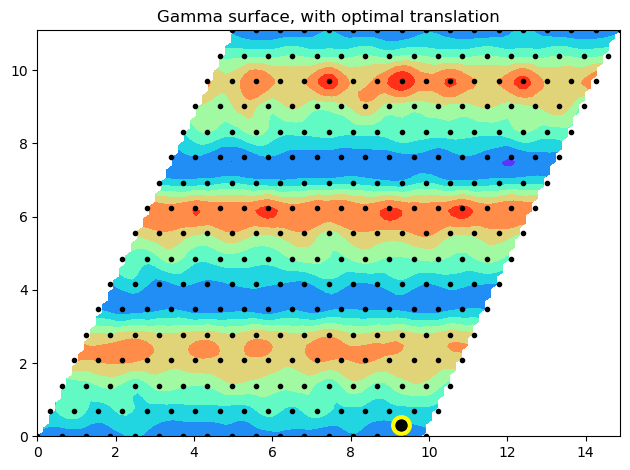

In [31]:
pe0 = -3.36
conv = 1.602*10.0

fig,axes = plt.subplots(1, 1)#, figsize=(2.0,2.0))
axis = axes
axis.set_title('Gamma surface, with optimal translation')
#axis.set_axis_off()

vmin = 0.0
vmax = 1.12
mine = 9999.0
maxe = -9999.0
numatoms, vectors = load_gamma_spec(gs_folder + 'gamma_spec.txt')
optima, dat = load_gamma_optima(gs_folder + 'gamma_optimised.txt')
# Extract gb energy
area = np.linalg.norm(np.cross(vectors[0,:],vectors[1,:]))
dat[:,3] = conv*(dat[:,3] - numatoms*pe0)/2.0/area
if np.min(dat[:,3]) < mine:
    mine = np.min(dat[:,3])
if np.max(dat[:,3]) > maxe:
    maxe = np.max(dat[:,3])
X = dat[:,0]*vectors[0,0] + dat[:,1]*vectors[1,0]
Y = dat[:,0]*vectors[0,1] + dat[:,1]*vectors[1,1]
Z = dat[:,3]
# create x-y points to be used in heatmap
xi = np.linspace(X.min(),X.max(),100)
yi = np.linspace(Y.min(),Y.max(),100)
# Z is a matrix of x-y values
zi = griddata((X, Y), Z, (xi[None,:], yi[:,None]), method='cubic')

CS = axis.contourf(xi, yi, zi, cmap=plt.cm.rainbow)#, vmin=vmin, vmax=vmax)
axis.plot(X,Y, 'k.')
axis.plot(optima[0]*vectors[0,0] + optima[1]*vectors[1,0],optima[0]*vectors[0,1] + (optima[1]-1)*vectors[1,1], marker='o', linestyle='none', markersize=12, markerfacecolor="black", markeredgecolor='yellow', markeredgewidth=3)
if optima[3]<=-1.0 or optima[3]>=3.0:
    axis.plot(optima[0]*vectors[0,0] + optima[1]*vectors[1,0],(optima[0])*vectors[0,1] + (optima[1]-1)*vectors[1,1], marker='x', linestyle='none', markersize=15, markerfacecolor="None", markeredgecolor='red', markeredgewidth=3)


fig.tight_layout()